# Snapshot Quick Check

Quick inspection for snapshot structure and missing data.

In [75]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Edit this date if needed
trade_day = "20260105"

snapshot_root = Path(r"D:/cbond_on/raw_data/snapshot/cbond/raw_data")
path = snapshot_root / "2026-01" / f"{trade_day}.parquet"
path

WindowsPath('D:/cbond_on/raw_data/snapshot/cbond/raw_data/2026-01/20260105.parquet')

In [76]:
df = pd.read_parquet(path)
df.head(3)

,code,trade_time,pre_close,last,open,high,low,close,volume,amount,...,ask_price4,ask_volume4,bid_price4,bid_volume4,ask_price5,ask_volume5,bid_price5,bid_volume5,iopv,trading_phase_code
0,118045.SH,2026-01-05 09:25:00,277.959,290.0,290.0,290.0,290.0,0.0,1201.0,3482900.0,...,290.9,3.0,289.2,12.0,291.0,10.0,289.0,123.0,0.0,T
1,118045.SH,2026-01-05 09:25:24,277.959,290.0,290.0,290.0,290.0,0.0,1201.0,3482900.0,...,290.9,3.0,289.2,12.0,291.0,10.0,289.0,123.0,0.0,T
2,118045.SH,2026-01-05 09:25:54,277.959,290.0,290.0,290.0,290.0,0.0,1201.0,3482900.0,...,290.9,3.0,289.2,12.0,291.0,10.0,289.0,123.0,0.0,T


In [77]:
print("rows:", len(df))
print("columns:", len(df.columns))
print("time range:", df["trade_time"].min(), "->", df["trade_time"].max())
print("codes:", df["code"].nunique())

# overall time interval stats (seconds)
df["trade_time"] = pd.to_datetime(df["trade_time"])
delta_all = df.sort_values(["code", "trade_time"]).groupby("code")["trade_time"].diff().dt.total_seconds()
delta_all.describe()

rows: 1616600
columns: 35
time range: 2026-01-05 09:25:00 -> 2026-01-05 15:01:00
codes: 386


count    1.616214e+06
mean     4.805765e+00
std      7.672451e+00
min      3.000000e+00
25%      3.000000e+00
50%      3.000000e+00
75%      3.000000e+00
max      1.170000e+02
Name: trade_time, dtype: float64

In [78]:
# filter to 09:35-11:30 and 13:00-14:30 (exclude lunch)
df = df.copy()
df["trade_time"] = pd.to_datetime(df["trade_time"])
start_dt = pd.Timestamp(trade_day + " 09:35:00")
lunch_start = pd.Timestamp(trade_day + " 11:30:00")
lunch_end = pd.Timestamp(trade_day + " 13:00:00")
end_dt = pd.Timestamp(trade_day + " 14:30:00")
mask = ((df["trade_time"] >= start_dt) & (df["trade_time"] <= lunch_start)) | ((df["trade_time"] >= lunch_end) & (df["trade_time"] <= end_dt))
df_window = df[mask]
print("window rows:", len(df_window))
print("window codes:", df_window["code"].nunique())
delta_window = df_window.sort_values(["code", "trade_time"]).groupby("code")["trade_time"].diff().dt.total_seconds()
delta_window.describe()


window rows: 1332050
window codes: 386


count    1.331664e+06
mean     5.129645e+00
std      9.192365e+01
min      3.000000e+00
25%      3.000000e+00
50%      3.000000e+00
75%      3.000000e+00
max      5.421000e+03
Name: trade_time, dtype: float64

In [79]:
# per-code min/max time gap (seconds), exclude lunch break
cdf = df_window.sort_values(["code", "trade_time"]).copy()
am = cdf[(cdf["trade_time"] >= start_dt) & (cdf["trade_time"] <= lunch_start)].copy()
pm = cdf[(cdf["trade_time"] >= lunch_end) & (cdf["trade_time"] <= end_dt)].copy()
am["gap_sec"] = am.groupby("code")["trade_time"].diff().dt.total_seconds()
pm["gap_sec"] = pm.groupby("code")["trade_time"].diff().dt.total_seconds()
gap_stats = pd.concat([am, pm], ignore_index=True).groupby("code")["gap_sec"].agg(["min", "max"]).sort_values("max", ascending=False)
gap_stats.head(10)


,min,max
code,,
123249.SZ,12.0,108.0
123072.SZ,3.0,105.0
128144.SZ,15.0,105.0
123175.SZ,3.0,93.0
123197.SZ,3.0,93.0
127069.SZ,3.0,90.0
123126.SZ,3.0,84.0
123129.SZ,3.0,81.0
127033.SZ,39.0,81.0


In [80]:
# per-code missing ratio based on 3s grid (09:35-14:30)
grid = pd.date_range(start_dt, end_dt, freq="3s")
expected_points = len(grid)
counts_by_code = df_window.groupby("code")["trade_time"].nunique()
missing_ratio = (1 - counts_by_code / expected_points).sort_values(ascending=False)


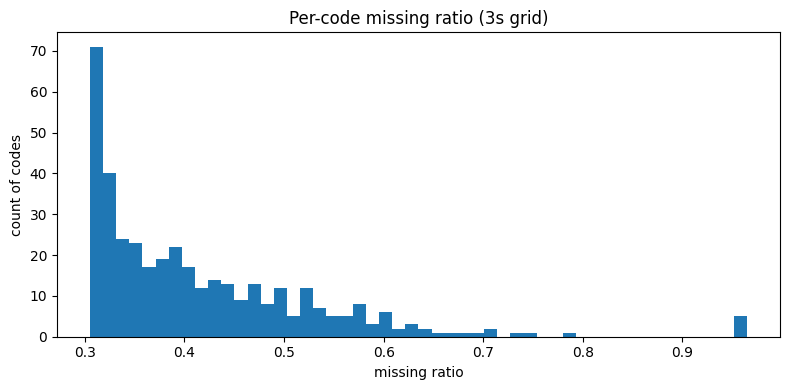

In [81]:
# distribution of per-code missing ratio (3s grid)
plt.figure(figsize=(8, 4))
plt.hist(missing_ratio, bins=50)
plt.title("Per-code missing ratio (3s grid)")
plt.xlabel("missing ratio")
plt.ylabel("count of codes")
plt.tight_layout()


In [82]:
# per-code record counts and sample coverage
counts = df.groupby("code")["trade_time"].size().sort_values(ascending=False)
counts.describe()

count     386.000000
mean     4188.082902
std       803.210954
min       336.000000
25%      3787.000000
50%      4414.000000
75%      4806.750000
max      4995.000000
Name: trade_time, dtype: float64

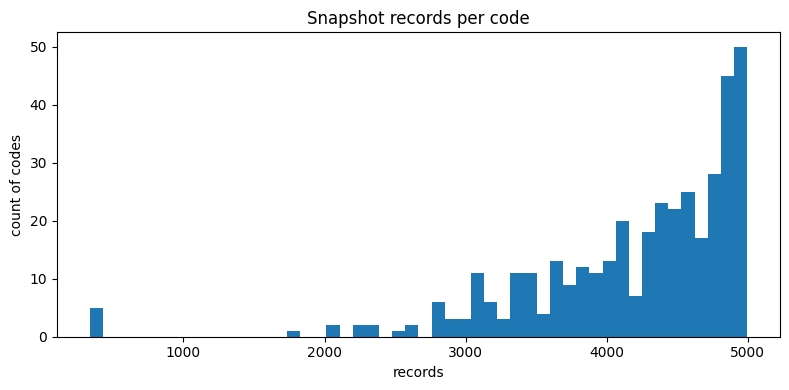

In [83]:
# histogram of counts per code
plt.figure(figsize=(8, 4))
plt.hist(counts, bins=50)
plt.title("Snapshot records per code")
plt.xlabel("records")
plt.ylabel("count of codes")
plt.tight_layout()